# Exploring Perturbative Nash Equilibrium

In [1]:
%load_ext autoreload
%autoreload 2

In [21]:
from src.game import get_hloc_from_graph, get_default_cyclic_players, H_QPD
import numpy as np

eps = 0.2
d = H_QPD.shape[-1]

def get_rand_normalized_herm_matrix(dtype: np.dtype = np.float32):
    if dtype == np.float32:
        rand_herm_matrix = np.random.randn(d, d)
        rand_herm_matrix = rand_herm_matrix + rand_herm_matrix.T
        rand_herm_matrix = rand_herm_matrix / np.linalg.norm(rand_herm_matrix)
    else:
        rand_herm_matrix = np.random.randn(d, d) + 1j * np.random.randn(d, d)
        rand_herm_matrix = rand_herm_matrix + rand_herm_matrix.T.conj()
        rand_herm_matrix = rand_herm_matrix / np.linalg.norm(rand_herm_matrix)

    return rand_herm_matrix

H_perturbed = [h + eps * get_rand_normalized_herm_matrix() for h in H_QPD]
Hs = get_default_cyclic_players(L=3, Hs=H_perturbed)

h = Hs[1].reshape(8, 8)
print(h)

[[ 3.09065258e+00 -6.12489571e-03  1.05616435e-02  4.45293620e-02
   2.07517803e-02  0.00000000e+00 -2.92906690e-02  0.00000000e+00]
 [-6.12489571e-03  1.57352178e+00 -2.45318327e-03 -1.43218870e-02
   0.00000000e+00  2.07517803e-02  0.00000000e+00 -2.92906690e-02]
 [ 1.05616435e-02 -2.45318327e-03  5.02552670e+00  2.02170603e-02
   9.14674006e-03  0.00000000e+00 -1.30729553e-02  0.00000000e+00]
 [ 4.45293620e-02 -1.43218870e-02  2.02170603e-02  3.00054810e+00
   0.00000000e+00  9.14674006e-03  0.00000000e+00 -1.30729553e-02]
 [ 2.07517803e-02  0.00000000e+00  9.14674006e-03  0.00000000e+00
   1.50402439e+00 -6.12489571e-03  5.19954547e-02  4.45293620e-02]
 [ 0.00000000e+00  2.07517803e-02  0.00000000e+00  9.14674006e-03
  -6.12489571e-03 -1.31064118e-02 -2.45318327e-03  2.71119243e-02]
 [-2.92906690e-02  0.00000000e+00 -1.30729553e-02  0.00000000e+00
   5.19954547e-02 -2.45318327e-03  3.02049696e+00  2.02170603e-02]
 [ 0.00000000e+00 -2.92906690e-02  0.00000000e+00 -1.30729553e-02
   

## Data Analysis

In [10]:
import pickle
import pandas as pd
import numpy as np
filename = "data/equilibrium_stats/eqdata_randstates_a0271d23.pkl"
df = pd.read_pickle(filename)
df = df.assign(tot_expl=df['expl'].apply(np.sum))
df[['nash_state', 'nash_equilibrium', 'tot_expl']]


,nash_state,nash_equilibrium,tot_expl
0,True,False,0.091793
1,False,True,0.000866
2,True,False,0.319757
3,False,True,0.000900
4,False,True,0.000904
5,True,False,0.043624
6,False,False,0.191765
7,True,False,0.113637
8,True,False,0.195035
9,True,False,0.053817


## Amount of non-commutativity

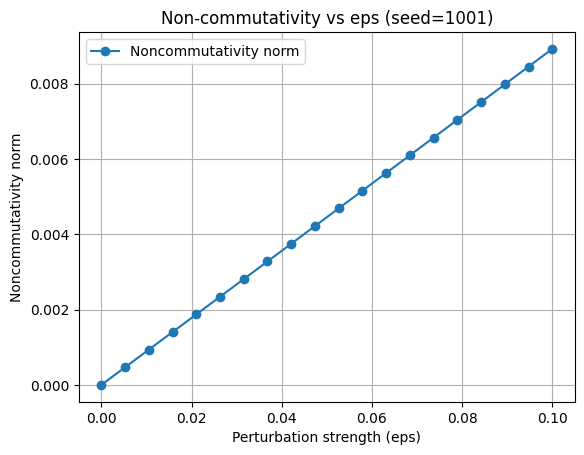

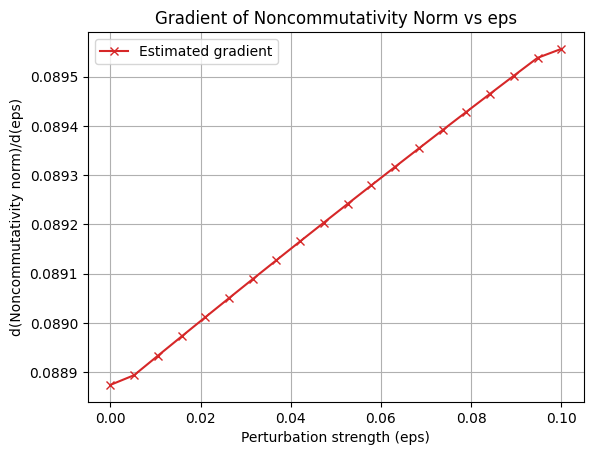

Gradient (min/max/mean): 0.0888741931159089 0.0895564239847377 0.0892198221388698


In [37]:
from src.game import get_perturbed_H_QPD
import numpy as np
np.set_printoptions(precision=3)
import matplotlib.pyplot as plt

def get_noncomm_norm(A, B) -> float:
    return np.linalg.norm(A @ B - B @ A) / (np.linalg.norm(A) * np.linalg.norm(B))

seed = 1001
epsilons = np.linspace(0, 0.1, 20)
noncomm_norms = []

for eps in epsilons:
    perturbed_H_QPD = get_perturbed_H_QPD(eps=eps, dtype=np.complex128, seed=seed)
    ncm = get_noncomm_norm(perturbed_H_QPD[0], perturbed_H_QPD[1])
    noncomm_norms.append(ncm)

plt.figure()
plt.plot(epsilons, noncomm_norms, marker='o', label='Noncommutativity norm')
plt.xlabel("Perturbation strength (eps)")
plt.ylabel("Noncommutativity norm")
plt.title(f"Non-commutativity vs eps (seed={seed})")
plt.legend()
plt.grid(True)
plt.show()

# Estimate the gradient d(noncomm_norm)/d(eps) using finite differences
noncomm_norms = np.array(noncomm_norms)
epsilons = np.array(epsilons)
grad = np.gradient(noncomm_norms, epsilons)

plt.figure()
plt.plot(epsilons, grad, marker='x', color='tab:red', label='Estimated gradient')
plt.xlabel("Perturbation strength (eps)")
plt.ylabel("d(Noncommutativity norm)/d(eps)")
plt.title("Gradient of Noncommutativity Norm vs eps")
plt.legend()
plt.grid(True)
plt.show()

# Print the estimated gradient at endpoints and mean
print("Gradient (min/max/mean):", grad.min(), grad.max(), grad.mean())
